# **Dataset Preparation**

## **Import Library**

In [1]:
!pip install pandas sqlalchemy psycopg2-binary matplotlib seaborn plotly atoti

In [2]:
from sqlalchemy import create_engine
import pandas as pd
import atoti as tt

Welcome to Atoti 0.9.15!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.


## **Load Dataset**

In [14]:
df = pd.read_csv("dataset/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **Cek Kolom Tahun**

In [15]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

## **Membuat Batch Periodik**

In [16]:
batch_2015 = df[df['arrival_date_year'] == 2015]
batch_2016 = df[df['arrival_date_year'] == 2016]
batch_2017 = df[df['arrival_date_year'] == 2017]

## **Validasi Jumlah Data**

In [17]:
print("Batch 2015:", batch_2015.shape)
print("Batch 2016:", batch_2016.shape)
print("Batch 2017:", batch_2017.shape)

Batch 2015: (21996, 32)
Batch 2016: (56707, 32)
Batch 2017: (40687, 32)


## **Simpan Tiap Batch**

In [18]:
batch_2015.to_csv('batch_2015.csv', index=False)
batch_2016.to_csv('batch_2016.csv', index=False)
batch_2017.to_csv('batch_2017.csv', index=False)

# **Pre-processor (Transform)**

## **Load Batch Dataset**

In [19]:
batch_2015 = pd.read_csv('batch_2015.csv')
batch_2016 = pd.read_csv('batch_2016.csv')
batch_2017 = pd.read_csv('batch_2017.csv')

## **Cek Ukuran Dataset**

In [20]:
print("Batch 2015:", batch_2015.shape)
print("Batch 2016:", batch_2016.shape)
print("Batch 2017:", batch_2017.shape)

Batch 2015: (21996, 32)
Batch 2016: (56707, 32)
Batch 2017: (40687, 32)


## **Gabungkan Semua Batch**

In [21]:
batches = {
    '2015': batch_2015,
    '2016': batch_2016,
    '2017': batch_2017
}

## **Membuat Dictionary untuk Hasil Transform**

In [22]:
transformed_batches = {}

## **Transform Batch 2015**

In [23]:
# Ambil batch 2015 dan buat copy
df = batches['2015'].copy()

# Cek missing value
print(df.isnull().sum())

# Handling missing value
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Remove duplicate
df = df.drop_duplicates()

# Convert datetime
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

# Time granularity
df['year'] = df['arrival_date_year']
df['month'] = df['reservation_status_date'].dt.month
df['quarter'] = df['reservation_status_date'].dt.quarter
df['day'] = df['reservation_status_date'].dt.day

# Rename column
df = df.rename(columns={
    'adr': 'average_daily_rate'
})

# Feature selection
selected_columns = [
    'hotel',
    'country',
    'adults',
    'children',
    'babies',
    'market_segment',
    'distribution_channel',
    'lead_time',
    'is_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'average_daily_rate',
    'year',
    'month',
    'quarter',
    'day'
]

df = df[selected_columns]

# Simpan hasil transformasi
transformed_batches['2015'] = df

# Preview
df.head()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             133
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              3099
company                           20691


,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,C,3,0,0,0.0,2015,7,3,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,C,4,0,0,0.0,2015,7,3,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,C,0,0,1,75.0,2015,7,3,2
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,A,0,0,1,75.0,2015,7,3,2
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,A,0,0,2,98.0,2015,7,3,3


## **Transform Batch 2016**

In [24]:
df = batches['2016'].copy()

# Cek missing value
print(df.isnull().sum())

# Handling missing value
df['children'] = df['children'].fillna(0)

df['country'] = df['country'].fillna('Unknown')

df['agent'] = df['agent'].fillna(0)

df['company'] = df['company'].fillna(0)

# Remove duplicate
df = df.drop_duplicates()

# Convert datetime
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date'], errors='coerce'
)

# Time granularity
df['year'] = df['arrival_date_year']

df['month'] = df['reservation_status_date'].dt.month

df['quarter'] = df['reservation_status_date'].dt.quarter

df['day'] = df['reservation_status_date'].dt.day

# Rename column
df = df.rename(columns={
    'adr': 'average_daily_rate'
})

# Feature selection
selected_columns = [

    'hotel',
    'country',
    'adults',
    'children',
    'babies',
    'market_segment',
    'distribution_channel',
    'lead_time',
    'is_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'average_daily_rate',
    'year',
    'month',
    'quarter',
    'day'
]

df = df[selected_columns]

# Simpan hasil
transformed_batches['2016'] = df

# Preview
df.head()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
country                             272
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              7577
company                           53525


,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,RUS,2,0.0,0,Online TA,TA/TO,109,0,A,D,0,0,1,59.94,2016,1,1,2
1,Resort Hotel,RUS,2,2.0,0,Online TA,TA/TO,109,0,H,H,0,0,1,116.10,2016,1,1,2
2,Resort Hotel,PRT,2,0.0,0,Online TA,TA/TO,2,1,D,D,0,0,1,89.00,2016,1,1,1
3,Resort Hotel,ARG,2,0.0,0,Online TA,TA/TO,88,0,A,D,0,0,2,73.46,2016,1,1,3
4,Resort Hotel,PRT,2,2.0,0,Online TA,TA/TO,20,1,G,G,0,0,2,119.00,2016,12,4,22


## **Transform Batch 2017**

In [25]:
df = batches['2017'].copy()

# Cek missing value
print(df.isnull().sum())

# Handling missing value
df['children'] = df['children'].fillna(0)

df['country'] = df['country'].fillna('Unknown')

df['agent'] = df['agent'].fillna(0)

df['company'] = df['company'].fillna(0)

# Remove duplicate
df = df.drop_duplicates()

# Convert datetime
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

# Time granularity
df['year'] = df['arrival_date_year']

df['month'] = df['reservation_status_date'].dt.month

df['quarter'] = df['reservation_status_date'].dt.quarter

df['day'] = df['reservation_status_date'].dt.day

# Rename column
df = df.rename(columns={
    'adr': 'average_daily_rate'
})

# Feature selection
selected_columns = [

    'hotel',
    'country',
    'adults',
    'children',
    'babies',
    'market_segment',
    'distribution_channel',
    'lead_time',
    'is_canceled',
    'reserved_room_type',
    'assigned_room_type',
    'booking_changes',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'average_daily_rate',
    'year',
    'month',
    'quarter',
    'day'
]

df = df[selected_columns]

# Simpan hasil
transformed_batches['2017'] = df

# Preview
df.head()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
country                              83
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              5664
company                           38377


,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Online TA,TA/TO,74,1,A,A,0,1,0,57.60,2017,10,4,20
1,Resort Hotel,AUT,2,0.0,0,Online TA,TA/TO,62,1,A,A,0,2,2,51.50,2017,12,4,4
2,Resort Hotel,AUT,2,0.0,0,Online TA,TA/TO,62,1,A,A,0,2,2,51.50,2017,11,4,11
4,Resort Hotel,PRT,1,0.0,0,Online TA,TA/TO,71,1,A,A,0,2,2,32.22,2017,10,4,29
5,Resort Hotel,ITA,2,0.0,0,Online TA,TA/TO,88,1,A,A,0,2,3,44.64,2017,11,4,20


## **Simpan Hasil Transform Batch 2015**

In [26]:
transformed_batches['2015'].to_csv(
    'transformed_batch_2015.csv',
    index=False
)

print("transformed_batch_2015.csv berhasil disimpan")

transformed_batch_2015.csv berhasil disimpan


## **Simpan Hasil Transform Batch 2016**

In [27]:
transformed_batches['2016'].to_csv(
    'transformed_batch_2016.csv',
    index=False
)

print("transformed_batch_2016.csv berhasil disimpan")

transformed_batch_2016.csv berhasil disimpan


## **Simpan Hasil Transform Batch 2017**

In [28]:
transformed_batches['2017'].to_csv(
    'transformed_batch_2017.csv',
    index=False
)

print("transformed_batch_2017.csv berhasil disimpan")

transformed_batch_2017.csv berhasil disimpan


## **Validasi Hasil Transform**

In [29]:
print("Batch 2015")
print(transformed_batches['2015'].shape)

print("\nBatch 2016")
print(transformed_batches['2016'].shape)

print("\nBatch 2017")
print(transformed_batches['2017'].shape)

Batch 2015
(13313, 19)

Batch 2016
(42391, 19)

Batch 2017
(31692, 19)


## **Preview Hasil Akhir**

In [30]:
transformed_batches['2015'].head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,C,3,0,0,0.0,2015,7,3,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,C,4,0,0,0.0,2015,7,3,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,C,0,0,1,75.0,2015,7,3,2
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,A,0,0,1,75.0,2015,7,3,2
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,A,0,0,2,98.0,2015,7,3,3


In [31]:
transformed_batches['2016'].head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,RUS,2,0.0,0,Online TA,TA/TO,109,0,A,D,0,0,1,59.94,2016,1,1,2
1,Resort Hotel,RUS,2,2.0,0,Online TA,TA/TO,109,0,H,H,0,0,1,116.10,2016,1,1,2
2,Resort Hotel,PRT,2,0.0,0,Online TA,TA/TO,2,1,D,D,0,0,1,89.00,2016,1,1,1
3,Resort Hotel,ARG,2,0.0,0,Online TA,TA/TO,88,0,A,D,0,0,2,73.46,2016,1,1,3
4,Resort Hotel,PRT,2,2.0,0,Online TA,TA/TO,20,1,G,G,0,0,2,119.00,2016,12,4,22


In [32]:
transformed_batches['2017'].head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Online TA,TA/TO,74,1,A,A,0,1,0,57.60,2017,10,4,20
1,Resort Hotel,AUT,2,0.0,0,Online TA,TA/TO,62,1,A,A,0,2,2,51.50,2017,12,4,4
2,Resort Hotel,AUT,2,0.0,0,Online TA,TA/TO,62,1,A,A,0,2,2,51.50,2017,11,4,11
4,Resort Hotel,PRT,1,0.0,0,Online TA,TA/TO,71,1,A,A,0,2,2,32.22,2017,10,4,29
5,Resort Hotel,ITA,2,0.0,0,Online TA,TA/TO,88,1,A,A,0,2,3,44.64,2017,11,4,20


# **Load To Postgresql / Supabase**

## **Load Hasil Transform**

In [33]:
df_2015 = pd.read_csv('transformed_batch_2015.csv')
df_2016 = pd.read_csv('transformed_batch_2016.csv')
df_2017 = pd.read_csv('transformed_batch_2017.csv')

## **Gabungkan Data**

In [34]:
fact_booking = pd.concat([
df_2015,
df_2016,
df_2017
], ignore_index=True)

print(fact_booking.shape)
fact_booking.info()

(87396, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hotel                    87396 non-null  object 
 1   country                  87396 non-null  object 
 2   adults                   87396 non-null  int64  
 3   children                 87396 non-null  float64
 4   babies                   87396 non-null  int64  
 5   market_segment           87396 non-null  object 
 6   distribution_channel     87396 non-null  object 
 7   lead_time                87396 non-null  int64  
 8   is_canceled              87396 non-null  int64  
 9   reserved_room_type       87396 non-null  object 
 10  assigned_room_type       87396 non-null  object 
 11  booking_changes          87396 non-null  int64  
 12  stays_in_weekend_nights  87396 non-null  int64  
 13  stays_in_week_nights     87396 non-null  int64  
 14  average_da

## **Koneksi Supabase**

In [35]:
DB_USER = 'postgres.rvkjeftaskrfkkkeiwpx'
DB_PASSWORD = 'datawarehouse_kelompok9'
DB_HOST = 'aws-1-ap-northeast-1.pooler.supabase.com'
DB_PORT = '5432'
DB_NAME = 'postgres'
DATABASE_URL = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require'

In [36]:
engine = create_engine(
f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print("Koneksi database berhasil!")

Koneksi database berhasil!


## **Load Fact Table**

In [77]:
fact_booking = pd.concat(

    [
        transformed_batches['2015'],
        transformed_batches['2016'],
        transformed_batches['2017']
    ],

    ignore_index=True

)

In [78]:
fact_booking.head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,C,3,0,0,0.0,2015,7,3,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,C,4,0,0,0.0,2015,7,3,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,C,0,0,1,75.0,2015,7,3,2
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,A,0,0,1,75.0,2015,7,3,2
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,A,0,0,2,98.0,2015,7,3,3


In [79]:
fact_booking.head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,C,3,0,0,0.0,2015,7,3,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,C,4,0,0,0.0,2015,7,3,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,C,0,0,1,75.0,2015,7,3,2
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,A,0,0,1,75.0,2015,7,3,2
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,A,0,0,2,98.0,2015,7,3,3


In [80]:
# Jalankan ini di Jupyter Notebook kamu, ini akan otomatis membuat tabel dan kolom yang sesuai
with engine.begin() as connection:
    fact_booking.to_sql(
        name='fact_booking', 
        con=connection,       
        if_exists='replace',  # Parameter ini yang akan otomatis membuat/mereset kolom di Supabase
        index=False,          
        chunksize=2000        
    )

In [82]:
# ## **Load Data ke Tabel Partisi Supabase**

# 1. Gabungkan seluruh batch tahun menjadi satu dataframe utama
fact_booking_all = pd.concat([
    transformed_batches['2015'], 
    transformed_batches['2016'], 
    transformed_batches['2017']
], ignore_index=True)

# 2. Targetkan ke nama TABEL INDUK (bukan tabel anak per tahun)
TABLE_PARENT = 'fact_hotel_partitioned'

print(f"Sedang mengunggah {len(fact_booking_all)} baris data ke tabel induk '{TABLE_PARENT}'...")

try:
    with engine.begin() as connection:
        fact_booking_all.to_sql(
            name=TABLE_PARENT, 
            con=connection,       
            if_exists='append',  # PENTING: Gunakan 'append' agar tidak merusak struktur partisi yang sudah kamu buat di SQL Editor
            index=False,          
            chunksize=2000        
        )
    print("\nBerhasil! PostgreSQL otomatis membagi data ke tabel 2015, 2016, dan 2017.")

except Exception as e:
    print("\nProses Upload Gagal!")
    print("Detail Error:", e)

Sedang mengunggah 87396 baris data ke tabel induk 'fact_hotel_partitioned'...

Berhasil! PostgreSQL otomatis membagi data ke tabel 2015, 2016, dan 2017.


In [81]:
from sqlalchemy import text

with engine.connect() as connection:
    connection.execute(
        text('DROP MATERIALIZED VIEW IF EXISTS monthly_booking_summary CASCADE;')
    )
    connection.commit()

fact_booking.to_sql(
    'fact_hotel_booking',
    engine,
    if_exists='replace',
    index=False
)

print("Fact table berhasil dibuat!")

Fact table berhasil dibuat!


## **Membuat Dimension Table**

## **Dimensi Waktu**

In [41]:
dim_time = fact_booking[
['year', 'month', 'quarter', 'day']
].drop_duplicates()

dim_time.to_sql(
'dim_time',
engine,
if_exists='replace',
index=False
)

print("dim_time berhasil dibuat!")

dim_time berhasil dibuat!


## **Dimensi Hotel**

In [42]:
dim_hotel = fact_booking[
['hotel']
].drop_duplicates()

dim_hotel.to_sql(
'dim_hotel',
engine,
if_exists='replace',
index=False
)

print("dim_hotel berhasil dibuat!")

dim_hotel berhasil dibuat!


## **Dimensi Negara**

In [43]:
dim_country = fact_booking[
['country']
].drop_duplicates()

dim_country.to_sql(
'dim_country',
engine,
if_exists='replace',
index=False
)

print("dim_country berhasil dibuat!")

dim_country berhasil dibuat!


## **Dimensi Market Segment**

In [44]:
dim_market_segment = fact_booking[
['market_segment']
].drop_duplicates()

dim_market_segment.to_sql(
'dim_market_segment',
engine,
if_exists='replace',
index=False
)

print("dim_market_segment berhasil dibuat!")

dim_market_segment berhasil dibuat!


# **Atoti DataMart**

## **Ambil Data Fact Table**

In [45]:
df = pd.read_sql(
    """
    SELECT *
    FROM fact_hotel_booking
    """,
    engine
)

df.head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,assigned_room_type,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,C,3,0,0,0.0,2015,7,3,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,C,4,0,0,0.0,2015,7,3,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,C,0,0,1,75.0,2015,7,3,2
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,A,0,0,1,75.0,2015,7,3,2
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,A,0,0,2,98.0,2015,7,3,3


## **Persiapan Data**

In [46]:
# ID unik
df["booking_id"] = range(1, len(df) + 1)

# Counter booking
df["booking_counter"] = 1

# Bersihkan null
df["year"] = df["year"].fillna(0).astype(int)
df["quarter"] = df["quarter"].fillna("Unknown")
df["month"] = df["month"].fillna("Unknown")
df["day"] = df["day"].fillna(0).astype(int)

df.head()

,hotel,country,adults,children,babies,market_segment,distribution_channel,lead_time,is_canceled,reserved_room_type,...,booking_changes,stays_in_weekend_nights,stays_in_week_nights,average_daily_rate,year,month,quarter,day,booking_id,booking_counter
0,Resort Hotel,PRT,2,0.0,0,Direct,Direct,342,0,C,...,3,0,0,0.0,2015,7,3,1,1,1
1,Resort Hotel,PRT,2,0.0,0,Direct,Direct,737,0,C,...,4,0,0,0.0,2015,7,3,1,2,1
2,Resort Hotel,GBR,1,0.0,0,Direct,Direct,7,0,A,...,0,0,1,75.0,2015,7,3,2,3,1
3,Resort Hotel,GBR,1,0.0,0,Corporate,Corporate,13,0,A,...,0,0,1,75.0,2015,7,3,2,4,1
4,Resort Hotel,GBR,2,0.0,0,Online TA,TA/TO,14,0,A,...,0,0,2,98.0,2015,7,3,3,5,1


## **Cek Struktur Tabel**

In [47]:
print(df.columns.tolist())

['hotel', 'country', 'adults', 'children', 'babies', 'market_segment', 'distribution_channel', 'lead_time', 'is_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'stays_in_weekend_nights', 'stays_in_week_nights', 'average_daily_rate', 'year', 'month', 'quarter', 'day', 'booking_id', 'booking_counter']


## **Buat Session**

In [48]:
session = tt.Session.start()

## **Load Data ke Atoti**

In [49]:
hotel_table = session.read_pandas(
    df,
    table_name="hotel_booking",
    keys={"booking_id"}
)

hotel_table

## **Buat Cube**

In [50]:
cube = session.create_cube(
    hotel_table,
    mode="manual"
)

h = cube.hierarchies
l = cube.levels
m = cube.measures

## **Buat Hierarchy**

In [51]:
# Hotel
h["Hotel"] = [
    hotel_table["hotel"]
]

# Country
h["Country"] = [
    hotel_table["country"]
]

# Market Segment
h["Market Segment"] = [
    hotel_table["market_segment"]
]

# Distribution Channel
h["Distribution Channel"] = [
    hotel_table["distribution_channel"]
]

# Room Type
h["Room Type"] = [
    hotel_table["reserved_room_type"],
    hotel_table["assigned_room_type"]
]

## **Buat Measures**

In [52]:
# Booking
m["Total Bookings"] = tt.agg.sum(
    hotel_table["booking_counter"]
)

m["Canceled Bookings"] = tt.agg.sum(
    hotel_table["is_canceled"]
)

m["Cancellation Rate"] = (
    m["Canceled Bookings"]
    / m["Total Bookings"]
)

# Guests
m["Total Adults"] = tt.agg.sum(
    hotel_table["adults"]
)

m["Total Children"] = tt.agg.sum(
    hotel_table["children"]
)

m["Total Babies"] = tt.agg.sum(
    hotel_table["babies"]
)

m["Total Guests"] = (
    m["Total Adults"]
    + m["Total Children"]
    + m["Total Babies"]
)

# Nights
m["Weekend Nights"] = tt.agg.sum(
    hotel_table["stays_in_weekend_nights"]
)

m["Week Nights"] = tt.agg.sum(
    hotel_table["stays_in_week_nights"]
)

m["Total Nights"] = (
    m["Weekend Nights"]
    + m["Week Nights"]
)

# Rate & lead time
m["Average Daily Rate"] = tt.agg.mean(
    hotel_table["average_daily_rate"]
)

m["Average Lead Time"] = tt.agg.mean(
    hotel_table["lead_time"]
)

# Revenue estimation
m["Estimated Revenue"] = (
    m["Average Daily Rate"]
    * m["Total Nights"]
)

# Stay duration
m["Average Stay Duration"] = (
    m["Total Nights"]
    / m["Total Bookings"]
)

## **Format Measure**

In [53]:
m["Total Bookings"].formatter = "INT[#,###]"
m["Canceled Bookings"].formatter = "INT[#,###]"
m["Cancellation Rate"].formatter = "DOUBLE[0.00%]"
m["Total Guests"].formatter = "INT[#,###]"
m["Total Nights"].formatter = "INT[#,###]"
m["Average Daily Rate"].formatter = "DOUBLE[#,###.00]"
m["Average Lead Time"].formatter = "DOUBLE[#,###.00]"
m["Estimated Revenue"].formatter = "DOUBLE[#,###.00]"
m["Average Stay Duration"].formatter = "DOUBLE[#,###.00]"

## **Test Query**

In [54]:
cube.query(
    m["Total Bookings"],
    m["Canceled Bookings"],
    m["Cancellation Rate"],
    m["Average Daily Rate"],
    m["Estimated Revenue"],
    levels=[l["hotel"]]
)

,Total Bookings,Canceled Bookings,Cancellation Rate,Average Daily Rate,Estimated Revenue
hotel,,,,,
City Hotel,"53,428","16,049",30.04%,110.99,"18,658,623.99"
Resort Hotel,"33,968","7,976",23.48%,99.03,"14,773,393.35"


## **Dimension**

In [55]:
cube.hierarchies

{('hotel_booking', 'Hotel'): <atoti.hierarchy.Hierarchy object at 0x0000016B792DE0B0>, ('hotel_booking', 'Country'): <atoti.hierarchy.Hierarchy object at 0x0000016B712F6140>, ('hotel_booking', 'Market Segment'): <atoti.hierarchy.Hierarchy object at 0x0000016B712F59C0>, ('hotel_booking', 'Distribution Channel'): <atoti.hierarchy.Hierarchy object at 0x0000016B712F59F0>, ('hotel_booking', 'Room Type'): <atoti.hierarchy.Hierarchy object at 0x0000016B712F7F10>}

## **Cek Level**

In [56]:
cube.levels

{('hotel_booking', 'Hotel', 'hotel'): <atoti.level.Level object at 0x0000016B712E2B00>, ('hotel_booking', 'Country', 'country'): <atoti.level.Level object at 0x0000016B712E0880>, ('hotel_booking', 'Market Segment', 'market_segment'): <atoti.level.Level object at 0x0000016B712E04F0>, ('hotel_booking', 'Distribution Channel', 'distribution_channel'): <atoti.level.Level object at 0x0000016B712E3130>, ('hotel_booking', 'Room Type', 'reserved_room_type'): <atoti.level.Level object at 0x0000016B712E2E90>, ('hotel_booking', 'Room Type', 'assigned_room_type'): <atoti.level.Level object at 0x0000016B712E3220>}

# **Dashboard**

## **KPI Summary**

In [57]:
cube.query(
    m["Total Bookings"],
    m["Canceled Bookings"],
    m["Cancellation Rate"],
    m["Average Daily Rate"],
    m["Estimated Revenue"]
)

,Total Bookings,Canceled Bookings,Cancellation Rate,Average Daily Rate,Estimated Revenue
0,"87,396","24,025",27.49%,106.34,"33,741,339.98"


## **Booking per Hotel (Bar Chart)**

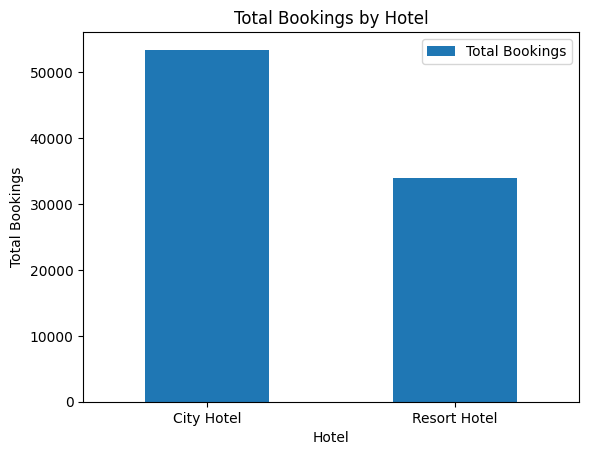

In [58]:
import matplotlib.pyplot as plt

hotel_df = cube.query(
    m["Total Bookings"],
    levels=[l["hotel"]]
)

hotel_df.plot(kind="bar")

plt.title("Total Bookings by Hotel")
plt.ylabel("Total Bookings")
plt.xlabel("Hotel")
plt.xticks(rotation=0)
plt.show()

## **Market Segment**

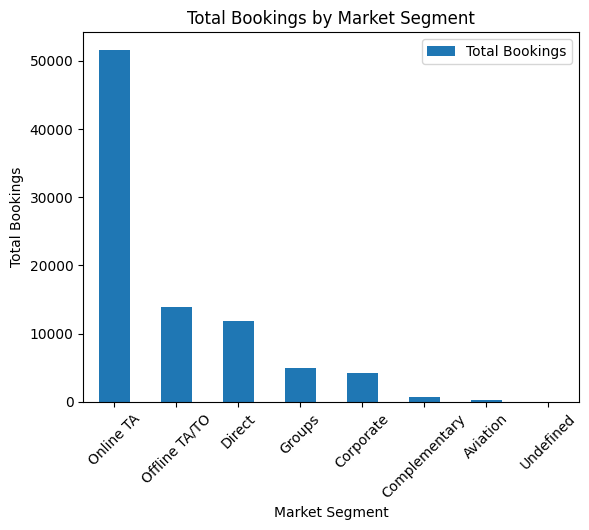

In [59]:
market_df = cube.query(
    m["Total Bookings"],
    levels=[l["market_segment"]]
)

market_df.sort_values(
    by="Total Bookings",
    ascending=False
).plot(kind="bar")

plt.title("Total Bookings by Market Segment")
plt.ylabel("Total Bookings")
plt.xlabel("Market Segment")
plt.xticks(rotation=45)
plt.show()

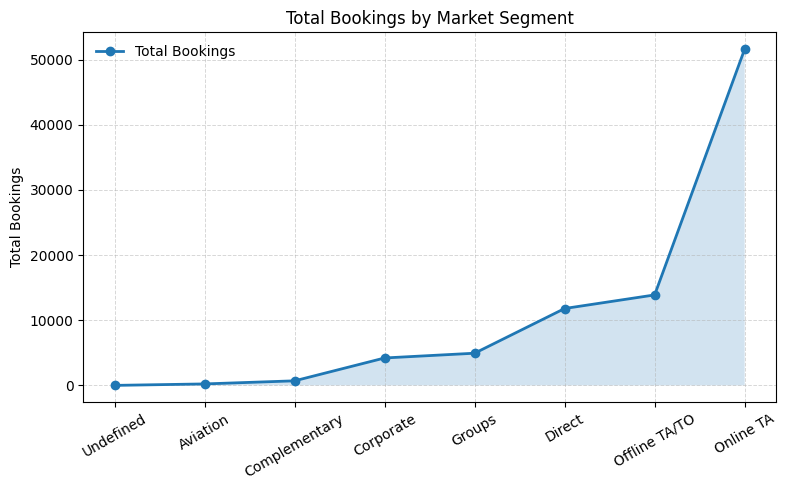

In [60]:
market_df = cube.query(
    m["Total Bookings"],
    levels=[l["market_segment"]]
)

market_df = market_df.sort_values(
    by="Total Bookings",
    ascending=True
)

x = range(len(market_df))
y = market_df["Total Bookings"].values

plt.figure(figsize=(8,5))

# garis + label legend
plt.plot(x, y, marker='o', linewidth=2, label="Total Bookings")

# area biru
plt.fill_between(x, y, alpha=0.2)

# grid
plt.grid(axis='both', linestyle='--', linewidth=0.7, alpha=0.5)

plt.xticks(x, market_df.index, rotation=30)

plt.title("Total Bookings by Market Segment")
plt.ylabel("Total Bookings")

# LEGEND DI KANAN 🔥
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), frameon=False)

plt.tight_layout()
plt.show()

## **Top Country**

<Axes: title={'center': 'Top 10 Countries by Total Bookings'}, xlabel='country'>

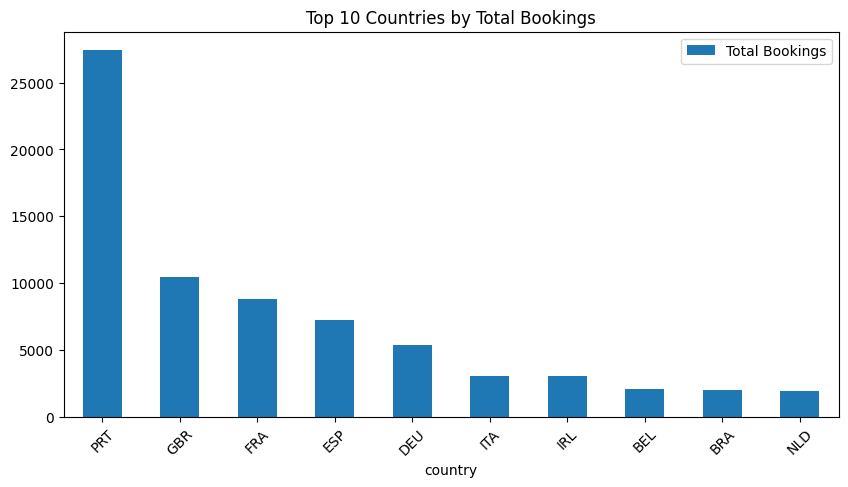

In [61]:
country_df = cube.query(
    m["Total Bookings"],
    levels=[l["country"]]
)

country_df.sort_values(
    by="Total Bookings",
    ascending=False
).head(10).plot.bar(
    title="Top 10 Countries by Total Bookings",
    figsize=(10,5),
    rot=45
)

## **Pie Chart Hotel**

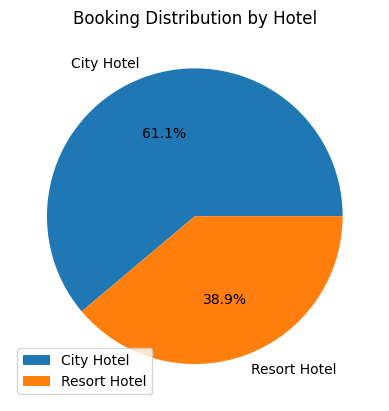

In [62]:
hotel_df = cube.query(
    m["Total Bookings"],
    levels=[l["hotel"]]
)

hotel_df.plot(
    kind="pie",
    y="Total Bookings",
    autopct="%1.1f%%"
)

plt.title("Booking Distribution by Hotel")
plt.ylabel("")
plt.show()

## **Pivot Table OLAP**

In [63]:
pivot_df = cube.query(
    m["Total Bookings"],
    m["Average Daily Rate"],
    m["Cancellation Rate"],
    levels=[
        l["hotel"],
        l["market_segment"]
    ]
)

pivot_df

Total Bookings Average Daily Rate  \
hotel        market_segment                                     
City Hotel   Aviation                  227             100.17   
             Complementary             513               2.75   
             Corporate               2,227              82.69   
             Direct                  5,559             120.85   
             Groups                  2,635              84.75   
             Offline TA/TO           7,271              87.28   
             Online TA              34,994             119.78   
             Undefined                   2              15.00   
Resort Hotel Complementary             189               3.87   
             Corporate               1,985              51.84   
             Direct                  6,245             112.78   
             Groups                  2,307              63.58   
             Offline TA/TO           6,618              75.71   
             Online TA              16,624             114.78   

                            Cancellation Rate  
hotel        market_segment                    
City Hotel   Aviation                  19.82%  
             Complementary             11.11%  
             Corporate                 11.85%  
             Direct                    16.41%  
             Groups                    33.78%  
             Offline TA/TO             17.34%  
             Online TA                 36.06%  
             Undefined                100.00%  
Resort Hotel Complementary             16.40%  
             Corporate                 12.39%  
             Direct                    13.21%  
             Groups                    19.29%  
             Offline TA/TO             12.12%  
             Online TA                 33.85%

## **Cancellation Rate by Hotel**

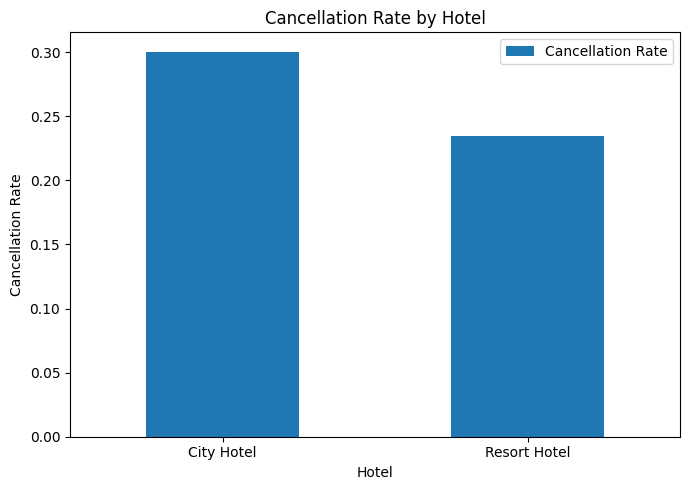

In [64]:
cancel_hotel_df = cube.query(
    m["Cancellation Rate"],
    levels=[l["hotel"]]
)

ax = cancel_hotel_df.plot(
    kind="bar",
    figsize=(7,5)
)

ax.set_title("Cancellation Rate by Hotel")
ax.set_xlabel("Hotel")
ax.set_ylabel("Cancellation Rate")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Estimated Revenue by Market Segment**

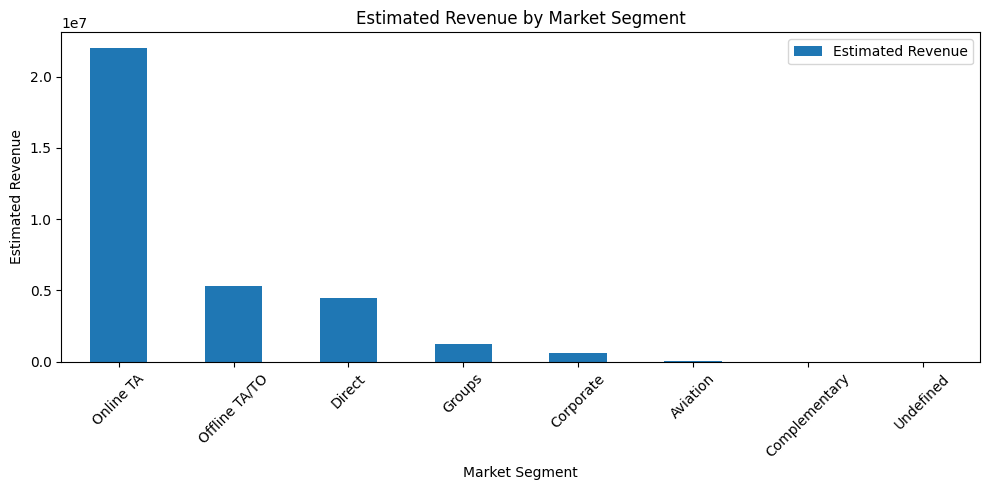

In [65]:
market_df = cube.query(
    m["Estimated Revenue"],
    levels=[l["market_segment"]]
)

market_df = market_df.sort_values(
    by="Estimated Revenue",
    ascending=False
)

ax = market_df.plot(
    kind="bar",
    figsize=(10,5)
)

ax.set_title("Estimated Revenue by Market Segment")
ax.set_xlabel("Market Segment")
ax.set_ylabel("Estimated Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Top 10 Countries by Total Bookings**

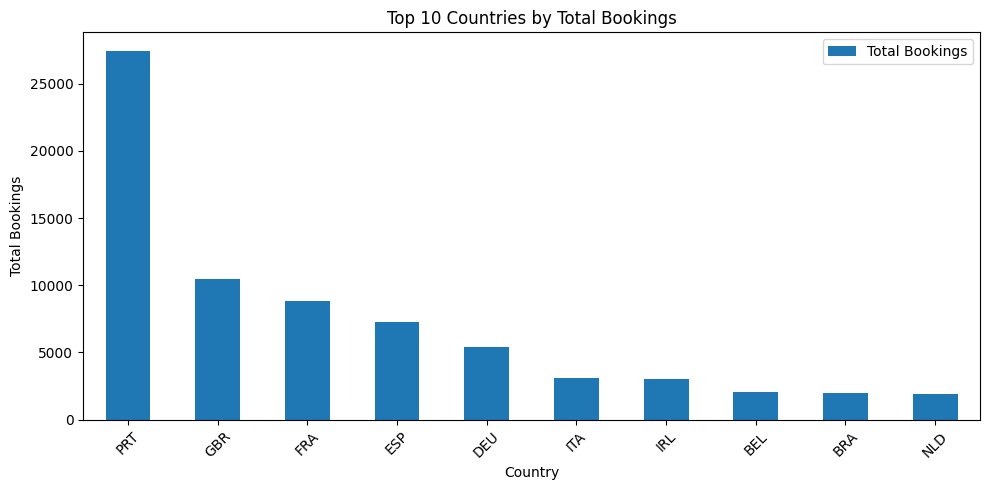

In [66]:
country_df = cube.query(
    m["Total Bookings"],
    levels=[l["country"]]
)

country_df = country_df.sort_values(
    by="Total Bookings",
    ascending=False
).head(10)

ax = country_df.plot(
    kind="bar",
    figsize=(10,5)
)

ax.set_title("Top 10 Countries by Total Bookings")
ax.set_xlabel("Country")
ax.set_ylabel("Total Bookings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


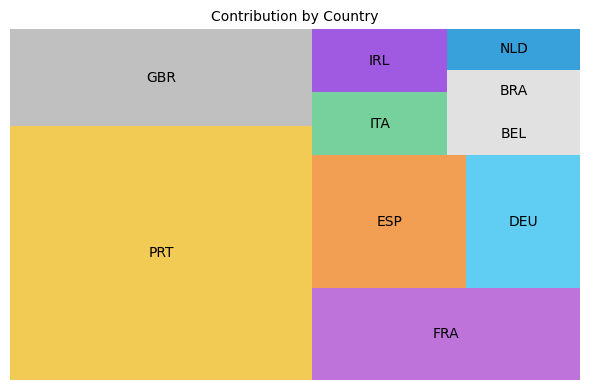

In [68]:
import squarify
import matplotlib.pyplot as plt

country_df = cube.query(
    m["Total Bookings"],
    levels=[l["country"]]
)

# top 10
country_df = country_df.sort_values(
    by="Total Bookings",
    ascending=False
).head(10)

labels = country_df.index
sizes = country_df["Total Bookings"].values

# 🔥 warna lebih variatif (ga banyak abu lagi)
color_map = {
    "PRT": "#F2C94C",  # kuning (utama)
    "GBR": "#BDBDBD",  # abu 1
    "FRA": "#BB6BD9",  # ungu
    "DEU": "#56CCF2",  # biru
    "IRL": "#9B51E0",  # ungu tua
    "ESP": "#F2994A",  # orange
    "ITA": "#6FCF97",  # hijau
    "USA": "#EB5757",  # merah
    "NLD": "#2D9CDB",  # biru tua
}

# default abu tapi cuma sedikit kepake
colors = [color_map.get(c, "#E0E0E0") for c in labels]

plt.figure(figsize=(6,4))

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.95
)

plt.title("Contribution by Country", fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

## **Average Daily Rate by Reserved Room Type**

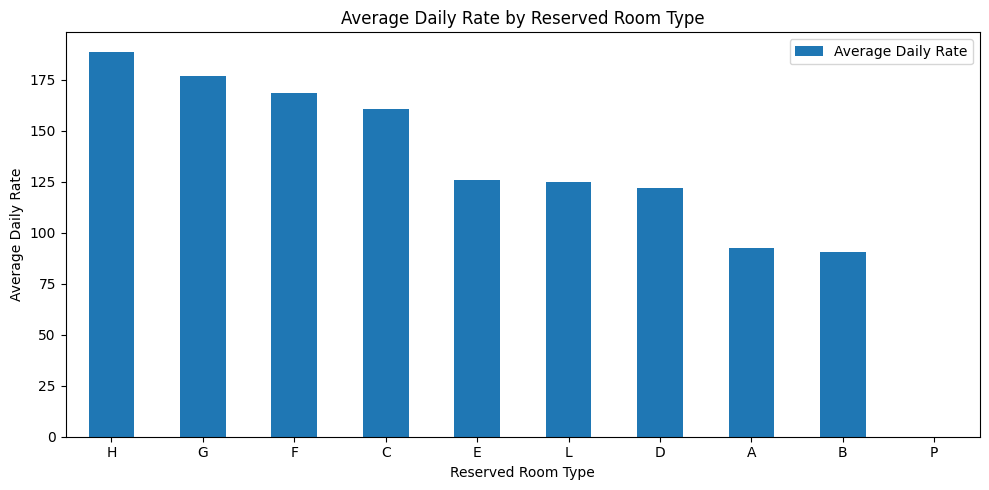

In [69]:
room_df = cube.query(
    m["Average Daily Rate"],
    levels=[l["reserved_room_type"]]
)

room_df = room_df.sort_values(
    by="Average Daily Rate",
    ascending=False
)

ax = room_df.plot(
    kind="bar",
    figsize=(10,5)
)

ax.set_title("Average Daily Rate by Reserved Room Type")
ax.set_xlabel("Reserved Room Type")
ax.set_ylabel("Average Daily Rate")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

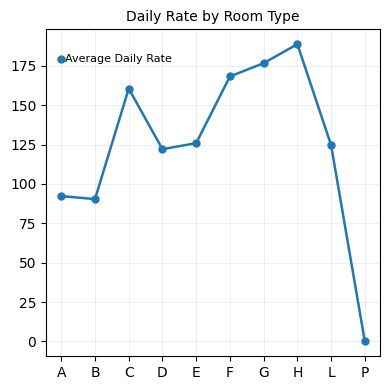

In [70]:
room_df = cube.query(
    m["Average Daily Rate"],
    levels=[l["reserved_room_type"]]
)

room_df = room_df.sort_index()

x = range(len(room_df))
y = room_df["Average Daily Rate"].values

plt.figure(figsize=(4,4))

# garis + titik utama
plt.plot(
    x, y,
    marker='o',
    linewidth=1.8,
    markersize=5
)

# grid
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)

# label x
plt.xticks(x, room_df.index)

# judul
plt.title("Daily Rate by Room Type", fontsize=10)

# 🔥 TITIK KECIL DI KIRI ATAS
legend_x = x[0]              # posisi kiri
legend_y = max(y) * 0.95     # posisi atas

plt.scatter(
    legend_x, legend_y,
    s=25                     # ukuran titik kecil
)

# 🔥 TEKS DI SAMPING TITIK
plt.text(
    legend_x + 0.1, legend_y,
    "Average Daily Rate",
    fontsize=8,
    va='center'
)

plt.tight_layout()
plt.show()

## **Total Bookings by Distribution Channel**

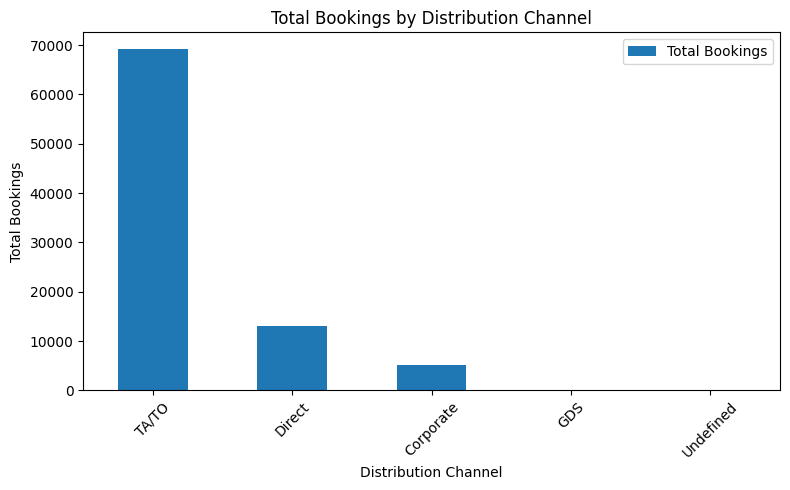

In [71]:
channel_df = cube.query(
    m["Total Bookings"],
    levels=[l["distribution_channel"]]
)

channel_df = channel_df.sort_values(
    by="Total Bookings",
    ascending=False
)

ax = channel_df.plot(
    kind="bar",
    figsize=(8,5)
)

ax.set_title("Total Bookings by Distribution Channel")
ax.set_xlabel("Distribution Channel")
ax.set_ylabel("Total Bookings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Menjalankan Atoti App**

In [72]:
type(session)

atoti.session.Session

In [73]:
session.url

'http://localhost:57503'

In [ ]:
session.close()